# Proyecto integrador — Parte I
## KDD, EDA y procesamiento distribuido con Apache Spark

**Dataset:** Órdenes de compra y licitaciones de ChileCompra, archivo `2007-1.csv`.

ChileCompra publica datos abiertos de las transacciones realizadas en Mercado Público para facilitar análisis, monitoreo y fiscalización. La descarga masiva cubre información desde 2007; este archivo corresponde al primer período de ese año. El portal documenta que los reportes usan CSV separado por punto y coma y que las órdenes se vinculan con organismos compradores, sector, proveedores y licitaciones. [Datos abiertos y cobertura](https://datos-abiertos.chilecompra.cl/descargas) · [conceptos de Mercado Público](https://datos-abiertos.chilecompra.cl/datos-abiertos/definiciones)

> **Alcance:** las descargas íntegras pueden incluir órdenes que ChileCompra excluye de sus cifras procesadas por errores de monto o moneda. Por tanto, los resultados de este notebook describen el archivo recibido; no deben presentarse como cifras oficiales sin contrastarlos con los datos complementarios del portal.

> **Grano crítico:** el CSV tiene una fila por ítem de orden de compra. Este notebook construye primero una tabla con una fila por `Codigo` (orden), de modo que `MontoTotalOC_PesosChilenos` no se sume repetidamente.

## 1. Preguntas de interés

1. **Concentración.** ¿Qué organismos, sectores, regiones y proveedores concentran el monto de las órdenes aceptadas?
2. **Composición y tiempo.** ¿Cómo cambia el monto y el número de ítems según el tipo de compra y durante el período observado?
3. **Canastas.** ¿Qué productos se compran conjuntamente dentro de una orden?

El proceso KDD se aplica en cinco etapas: selección de campos y del período; perfilado y control de calidad; transformación desde líneas de ítem a órdenes; minería mediante agregaciones distribuidas y canastas; e interpretación con límites explícitos.

| Etapa KDD | Aplicación en este notebook |
| --- | --- |
| Selección | Se conservan las columnas que identifican orden, fecha, estado, comprador, proveedor, producto y monto. |
| Preprocesamiento | Se reconoce `NA` como nulo, se valida el grano y se revisan montos ausentes, no positivos o inconsistentes. |
| Transformación | Las líneas se agregan en una tabla de una fila por orden y se derivan fecha, año, mes, canasta y número de ítems. |
| Minería | Spark produce series, rankings, concentración y la prueba de viabilidad de canastas. |
| Interpretación | Las conclusiones se delimitan por estado de orden, cobertura, grano y semántica de cada monto. |

El portal señala que los archivos de **licitaciones** pueden incluir ofertas, pero el CSV recibido no contiene un identificador de oferta, un postor ni un valor ofertado por licitación. Por ello no se infiere competencia a partir de `NombreProveedor`, que corresponde al proveedor de la orden. La competencia requiere otra descarga al grano de licitación–oferta.

## 2. Entorno e ingesta

El archivo se detectó como ISO-8859-1 y contiene texto multilínea; ambos parámetros son necesarios para que Spark no desplace columnas cuando una observación trae saltos de línea. Todos los campos se leen inicialmente como texto para preservar códigos, RUT y ceros a la izquierda; las fechas y montos se convierten después de comprobar su forma.

Spark se usa en modo local. Es una ejecución de un nodo: permite revisar proyección de columnas, agregaciones, particiones y el contraste RDD–DataFrame, pero no demuestra escalabilidad horizontal. Como `multiLine=True` impide partir libremente el archivo, se emplean dos hilos y no se cachea el CSV crudo; el primer artefacto reutilizable es el Parquet a grano de orden.

In [1]:
from pathlib import Path
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

RAIZ = Path.cwd()
ARCHIVO = RAIZ / '2007-1.csv'
assert ARCHIVO.exists(), f'No se encontró {ARCHIVO}'

# El CSV multilínea se lee en una sola partición: dos hilos evitan sobreasignar memoria.
spark = (SparkSession.builder.master('local[2]').appName('P1-ChileCompra-2007-1')
         .config('spark.driver.memory', '1g')
         .config('spark.sql.shuffle.partitions', '16')
         .config('spark.sql.adaptive.enabled', 'true').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
print(f'Archivo: {ARCHIVO.name} ({ARCHIVO.stat().st_size / 1e6:.1f} MB)')
print('Spark:', spark.version, '| núcleos:', spark.sparkContext.defaultParallelism)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/13 12:29:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Archivo: 2007-1.csv (328.3 MB)
Spark: 4.2.0 | núcleos: 16


In [2]:
t0 = time.perf_counter()
raw = (spark.read.option('header', True).option('sep', ';')
       .option('encoding', 'ISO-8859-1').option('multiLine', True)
       .option('quote', '\"').option('escape', '\"').option('nullValue', 'NA')
       .csv(str(ARCHIVO)))
n_lineas = raw.count()
print(f'Filas de ítem: {n_lineas:,}; columnas: {len(raw.columns)}; lectura: {time.perf_counter()-t0:.1f} s')
raw.printSchema()
raw.limit(5).toPandas().T

26/09/13 12:29:49 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Filas de ítem: 297,555; columnas: 78; lectura: 24.3 s
root
 |-- ID: string (nullable = true)
 |-- Codigo: string (nullable = true)
 |-- Link: string (nullable = true)
 |-- Nombre: string (nullable = true)
 |-- Descripcion/Obervaciones: string (nullable = true)
 |-- Tipo: string (nullable = true)
 |-- ProcedenciaOC: string (nullable = true)
 |-- EsTratoDirecto: string (nullable = true)
 |-- EsCompraAgil: string (nullable = true)
 |-- CodigoTipo: string (nullable = true)
 |-- CodigoAbreviadoTipoOC: string (nullable = true)
 |-- DescripcionTipoOC: string (nullable = true)
 |-- idPlanDeCompra: string (nullable = true)
 |-- codigoEstado: string (nullable = true)
 |-- Estado: string (nullable = true)
 |-- codigoEstadoProveedor: string (nullable = true)
 |-- EstadoProveedor: string (nullable = true)
 |-- FechaCreacion: string (nullable = true)
 |-- FechaEnvio: string (nullable = true)
 |-- FechaSolicitudCancelacion: string (nullable = true)
 |-- fechaUltimaModificacion: string (nullable = tru

,0,1,2,3,4
ID,1884444,1913102,1928466,1960425,1980185
Codigo,2258-151-OC06,2258-261-C106,2258-273-C106,820-10-OC06,2258-337-C106
Link,http://www.mercadopublico.cl/PurchaseOrder/Mod...,http://www.mercadopublico.cl/PurchaseOrder/Mod...,http://www.mercadopublico.cl/PurchaseOrder/Mod...,http://www.mercadopublico.cl/PurchaseOrder/Mod...,http://www.mercadopublico.cl/PurchaseOrder/Mod...
Nombre,OC Generada desde la Adquisición 2258-1183-CO05,PASAJES,pasajes,OC Generada desde la Adquisición 820-54-CO05,MANTENCION CORRECTIVA PARA AUTOCLAVE
Descripcion/Obervaciones,ESTA ES SOLO UNA REGULARIZACION DE LA O/C. INT...,"NO DESPACHAR MERCADERIA, ESTA ES SOLO UNA REGU...","NO DESPACHAR MERCADERIA, ESTA ES SOLO UNA REGU...",Prestacion de servicio de rev. proy electrico-...,"NO DESPACHAR MERCADERIA, ESTA ES SOLO UNA REGU..."
...,...,...,...,...,...
totalCargos,0,0,0,0,0
totalDescuentos,0,0,0,0,0
totalImpuestos,0,0,0,0,0
totalLineaNeto,2600000,682475,1125365,250000,835590


## 3. Perfilado y calidad

Se perfilan nulos y cardinalidad aproximada solo en las columnas analíticas: claves, fechas, estado, organismo, sector, región, proveedor, producto y montos. La cardinalidad es exploratoria; identifica posibles claves y categorías, no sustituye una validación exacta cuando una decisión depende de ella.

Dos controles son determinantes. Primero, `Codigo` identifica la orden y la combinación `Codigo`–`IDItem` identifica una línea lógica. Segundo, una orden puede repetir sus metadatos y su monto total en varias filas porque contiene varios ítems. Sumar `MontoTotalOC_PesosChilenos` antes de agrupar por `Codigo` multiplicaría el gasto según el tamaño de la canasta.

In [3]:
campos_perfil = ['Codigo', 'CodigoLicitacion', 'FechaEnvio', 'FechaCreacion', 'Estado',
                  'DescripcionTipoOC', 'OrganismoPublico', 'sector', 'RegionUnidadCompra',
                  'CodigoProveedor', 'NombreProveedor', 'RegionProveedor', 'IDItem',
                  'codigoProductoONU', 'Categoria', 'RubroN1', 'MontoTotalOC_PesosChilenos',
                  'totalLineaNeto']
agregados_perfil = []
for c in campos_perfil:
    agregados_perfil += [
        F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ''), c)).alias(f'{c}__nulos'),
        F.approx_count_distinct(c).alias(f'{c}__card'),
    ]
perfil = raw.agg(*agregados_perfil).toPandas().T.reset_index(names='medida')
perfil[['campo', 'metrica']] = perfil['medida'].str.rsplit('__', n=1, expand=True)
perfil = perfil.pivot(index='campo', columns='metrica', values=0).sort_values('nulos', ascending=False)
perfil.head(20)

/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


26/09/13 12:30:13 WARN DAGScheduler: Broadcasting large task binary with size 1310.8 KiB


26/09/13 12:30:25 WARN DAGScheduler: Broadcasting large task binary with size 1999.4 KiB


metrica,card,nulos
campo,,
ActividadComprador,0,297555
ActividadProveedor,0,297555
idPlanDeCompra,0,297555
FechaCancelacion,0,297555
FechaSolicitudCancelacion,0,297555
Financiamiento,0,297555
ComunaProveedor,101,295592
PaisUnidadCompra,1,295592
PaisProveedor,1,295592


In [4]:
calidad = raw.agg(
    F.count('*').alias('lineas'),
    F.countDistinct('Codigo').alias('ordenes_distintas'),
    F.countDistinct(F.struct('Codigo', 'IDItem')).alias('claves_orden_item'),
    F.sum(F.when(F.col('Codigo').isNull(), 1).otherwise(0)).alias('lineas_sin_codigo'),
    F.sum(F.when(F.col('IDItem').isNull(), 1).otherwise(0)).alias('lineas_sin_item'),
).toPandas().T.rename(columns={0: 'valor'})
calidad
# Si claves_orden_item es menor que lineas, hay duplicados exactos de la llave lógica.

/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,valor
lineas,297555
ordenes_distintas,97226
claves_orden_item,297555
lineas_sin_codigo,0
lineas_sin_item,0


## 4. Transformación: de ítems a órdenes

`MontoTotalOC_PesosChilenos` se toma con `max` dentro de cada orden, nunca con suma: es un atributo repetido a nivel de cabecera. La suma de `totalLineaNeto` se conserva como control independiente cuando está disponible. Si una misma orden presenta más de un monto total informado, se marca en `montos_oc_reportados` y no se oculta la inconsistencia. Los importes analizados se expresan en pesos chilenos (CLP).

También se construyen `n_items` y `productos_onu`. El código ONU se usa en Mercado Público para clasificar productos y servicios; por eso es una representación más estable para canastas que el texto libre de la especificación. [ChileCompra sobre código ONU](https://www.chilecompra.cl/licitacion-proveedor/)

La fecha temporal elegida es `FechaEnvio`: describe cuándo se envió la orden al proveedor. `FechaCreacion` queda conservada para auditoría porque una orden puede haberse creado antes de ser enviada.

In [5]:
def texto(nombre):
    return F.when(F.trim(F.col(nombre)).isin('', 'NA', 'N/A'), None).otherwise(F.trim(F.col(nombre)))

def entero_clp(nombre):
    return F.regexp_replace(F.trim(F.col(nombre)), r'[^0-9-]', '').cast('long')

lineas = (raw.filter(texto('Codigo').isNotNull())
    .select(
        texto('Codigo').alias('codigo_oc'), texto('CodigoLicitacion').alias('codigo_licitacion'),
        F.to_date(texto('FechaEnvio')).alias('fecha_envio'),
        F.to_date(texto('FechaCreacion')).alias('fecha_creacion'),
        texto('Estado').alias('estado_oc'), texto('EstadoProveedor').alias('estado_proveedor'),
        texto('DescripcionTipoOC').alias('tipo_oc'), texto('EsTratoDirecto').alias('es_trato_directo'),
        texto('EsCompraAgil').alias('es_compra_agil'), texto('OrganismoPublico').alias('organismo'),
        texto('sector').alias('sector'), texto('RegionUnidadCompra').alias('region_compra'),
        texto('CodigoProveedor').alias('codigo_proveedor'), texto('NombreProveedor').alias('proveedor'),
        texto('RegionProveedor').alias('region_proveedor'), texto('IDItem').alias('id_item'),
        texto('codigoProductoONU').alias('codigo_producto_onu'), texto('Categoria').alias('categoria'),
        texto('RubroN1').alias('rubro_n1'), texto('NombreroductoGenerico').alias('producto'),
        entero_clp('MontoTotalOC_PesosChilenos').alias('monto_oc_clp'),
        entero_clp('totalLineaNeto').alias('total_linea_neto_clp')
    ))

ordenes = (lineas.groupBy('codigo_oc').agg(
    *[F.first(c, ignorenulls=True).alias(c) for c in [
        'codigo_licitacion', 'fecha_envio', 'fecha_creacion', 'estado_oc', 'estado_proveedor',
        'tipo_oc', 'es_trato_directo', 'es_compra_agil', 'organismo', 'sector', 'region_compra',
        'codigo_proveedor', 'proveedor', 'region_proveedor'
    ]],
    F.max('monto_oc_clp').alias('monto_oc_clp'),
    F.sum('total_linea_neto_clp').alias('monto_lineas_neto_clp'),
    F.countDistinct('id_item').alias('n_items'),
    F.collect_set('codigo_producto_onu').alias('productos_onu'),
    F.countDistinct('monto_oc_clp').alias('montos_oc_reportados')
).withColumn('anio', F.year('fecha_envio')).withColumn('mes', F.month('fecha_envio'))
 .withColumn('anio_mes', F.date_trunc('month', 'fecha_envio')))
n_ordenes = ordenes.count()
print(f'Órdenes analíticas: {n_ordenes:,}')

Órdenes analíticas: 97,226


In [6]:
control_montos = ordenes.agg(
    F.sum(F.when(F.col('montos_oc_reportados') > 1, 1).otherwise(0)).alias('ocs_con_montos_inconsistentes'),
    F.sum(F.when(F.col('monto_oc_clp').isNull(), 1).otherwise(0)).alias('ocs_sin_monto_clp'),
    F.sum(F.when(F.col('monto_oc_clp') <= 0, 1).otherwise(0)).alias('ocs_monto_no_positivo'),
    F.sum(F.when(F.col('n_items') > 1, 1).otherwise(0)).alias('ocs_con_multiples_items'),
).toPandas().T.rename(columns={0: 'ordenes'})
control_montos
# Si hay inconsistencias, se conservan y se excluyen solo de agregados monetarios explícitamente filtrados.

/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,ordenes
ocs_con_montos_inconsistentes,0
ocs_sin_monto_clp,0
ocs_monto_no_positivo,0
ocs_con_multiples_items,39287


## 5. Persistencia y esquema final

La tabla analítica se escribe en Parquet particionado por año de envío. Parquet conserva tipos, evita volver a parsear el CSV y permite que Spark descarte directorios completos cuando una consulta filtra por `anio`.

La escritura usa `overwrite` para que el notebook sea repetible, pero la ruta está aislada en `salida_p1_chilecompra/ordenes_parquet`. Cambia `RUTA_PARQUET` si necesitas conservar ejecuciones o versiones distintas del archivo fuente.

In [7]:
RUTA_PARQUET = RAIZ / 'salida_p1_chilecompra' / 'ordenes_parquet'
ordenes.write.mode('overwrite').partitionBy('anio').parquet(str(RUTA_PARQUET))
datos = spark.read.parquet(str(RUTA_PARQUET))
datos.createOrReplaceTempView('ordenes_chilecompra')
datos.printSchema()
datos.select('codigo_oc', 'fecha_envio', 'organismo', 'proveedor', 'monto_oc_clp', 'n_items').show(5, truncate=28)

26/09/13 12:30:55 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/13 12:30:55 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/13 12:30:55 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/13 12:30:55 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/13 12:30:55 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/13 12:30:55 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/13 12:30:55 WARN MemoryManager: Total allocation exceeds 95.

26/09/13 12:30:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 50.67% for 15 writers
26/09/13 12:30:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 54.29% for 14 writers
26/09/13 12:30:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/13 12:30:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/13 12:30:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/13 12:30:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/13 12:30:58 WARN MemoryManager: Total allocation exceeds 9

root
 |-- codigo_oc: string (nullable = true)
 |-- codigo_licitacion: string (nullable = true)
 |-- fecha_envio: date (nullable = true)
 |-- fecha_creacion: date (nullable = true)
 |-- estado_oc: string (nullable = true)
 |-- estado_proveedor: string (nullable = true)
 |-- tipo_oc: string (nullable = true)
 |-- es_trato_directo: string (nullable = true)
 |-- es_compra_agil: string (nullable = true)
 |-- organismo: string (nullable = true)
 |-- sector: string (nullable = true)
 |-- region_compra: string (nullable = true)
 |-- codigo_proveedor: string (nullable = true)
 |-- proveedor: string (nullable = true)
 |-- region_proveedor: string (nullable = true)
 |-- monto_oc_clp: long (nullable = true)
 |-- monto_lineas_neto_clp: long (nullable = true)
 |-- n_items: long (nullable = true)
 |-- productos_onu: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- montos_oc_reportados: long (nullable = true)
 |-- mes: integer (nullable = true)
 |-- anio_mes: timestamp (nul

+------------+-----------+----------------------------+-------------------------+------------+-------+
|   codigo_oc|fecha_envio|                   organismo|                proveedor|monto_oc_clp|n_items|
+------------+-----------+----------------------------+-------------------------+------------+-------+
| 1002-3-CM07| 2007-01-26|MINISTERIO DE OBRAS PUBLI...|LATAM AIRLINES GROUP S.A.|      206690|      1|
|1003-17-CM07| 2007-01-11|MINISTERIO DE OBRAS PUBLI...|     RED OFFICE SUR LTDA.|    22748278|      3|
|1003-26-CM07| 2007-01-24|MINISTERIO DE OBRAS PUBLI...|LATAM AIRLINES GROUP S.A.|      296216|      1|
| 1003-6-G107| 2007-01-09|MINISTERIO DE OBRAS PUBLI...|            Inverfut EIRL|         305|      1|
| 1016-8-SE07| 2007-01-24|Dirección de Planeamiento...|       Egm world Cia Ltda|     1345176|      1|
+------------+-----------+----------------------------+-------------------------+------------+-------+
only showing top 5 rows


## 6. EDA: tiempo, tipos y monto

Los agregados se hacen sobre `datos`, que tiene una fila por orden. Solo se trasladan a pandas tablas pequeñas ya agregadas para graficar; llevar las 97 mil órdenes completas al controlador no aporta nada a estas figuras.

La serie mensual usa órdenes con monto positivo. No se interpreta una caída de un mes como evidencia de menor actividad sin revisar los estados, las fechas faltantes y la cobertura del archivo. Como se trata de 2007, las modalidades creadas después —por ejemplo Compra Ágil, habilitada en 2020— no deben compararse con los mecanismos vigentes actuales. [Definición de Compra Ágil](https://datos-abiertos.chilecompra.cl/datos-abiertos/definiciones)

La distribución de montos se grafica en escala logarítmica: las órdenes públicas suelen tener cola larga y la escala lineal concentraría la mayor parte de las observaciones junto al origen. La media y la mediana se reportan juntas para hacer visible esa asimetría.

/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


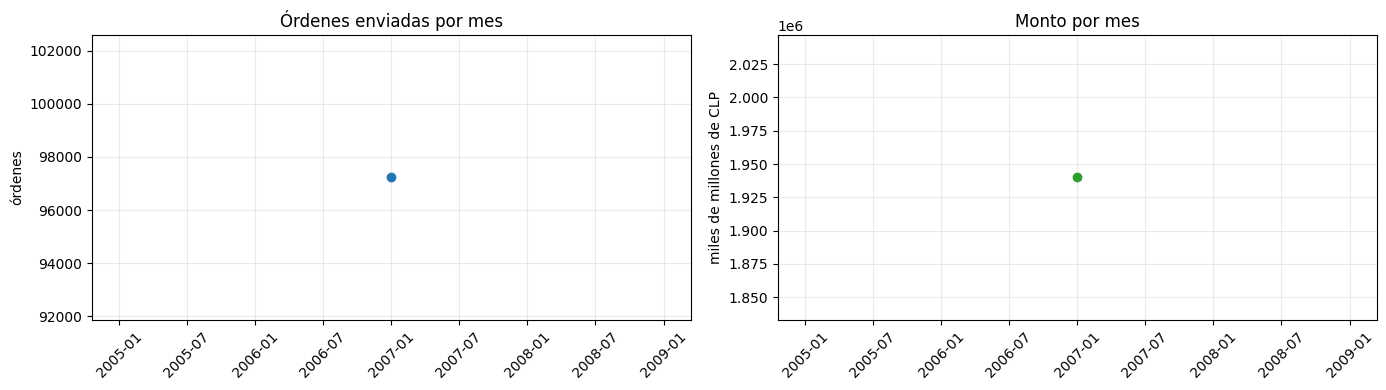

,anio_mes,ordenes,monto_miles_millones
0,2007-01-01,97226,1.939926e+06


In [8]:
mensual = spark.sql('''
    SELECT anio_mes, COUNT(*) AS ordenes, SUM(monto_oc_clp) / 1e9 AS monto_miles_millones
    FROM ordenes_chilecompra
    WHERE monto_oc_clp > 0
    GROUP BY anio_mes ORDER BY anio_mes
''').toPandas()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(mensual['anio_mes'], mensual['ordenes'], marker='o'); ax[0].set(title='Órdenes enviadas por mes', ylabel='órdenes')
ax[1].plot(mensual['anio_mes'], mensual['monto_miles_millones'], marker='o', color='tab:green'); ax[1].set(title='Monto por mes', ylabel='miles de millones de CLP')
for a in ax: a.tick_params(axis='x', rotation=45); a.grid(alpha=.25)
plt.tight_layout(); plt.show()
mensual

/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


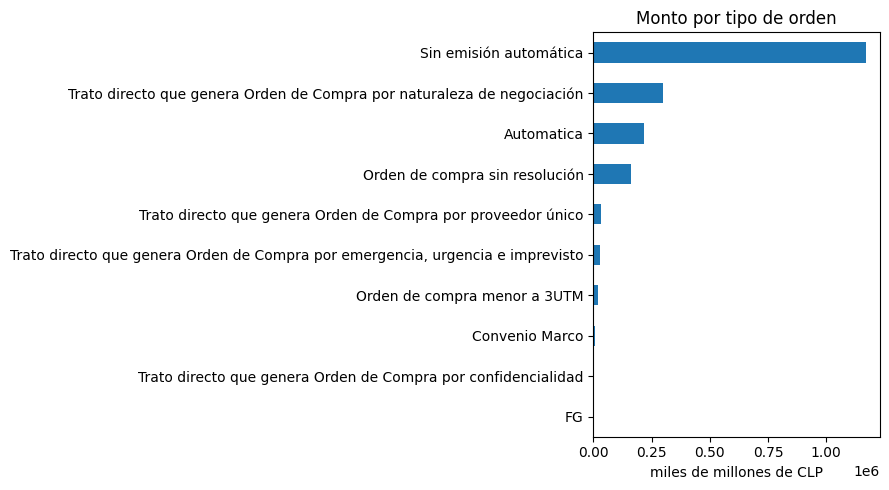

,tipo_oc,ordenes,monto_miles_millones,items_medianos
0,Sin emisión automática,10319,1.172416e+06,1
1,Trato directo que genera Orden de Compra por n...,2346,3.010349e+05,1
2,Automatica,36975,2.190304e+05,1
3,Orden de compra sin resolución,13342,1.626417e+05,1
4,Trato directo que genera Orden de Compra por p...,3871,3.170302e+04,1
5,Trato directo que genera Orden de Compra por e...,1957,2.730054e+04,1
6,Orden de compra menor a 3UTM,10720,1.901844e+04,1
7,Convenio Marco,17466,5.447533e+03,1
8,Trato directo que genera Orden de Compra por c...,95,1.312425e+03,1
9,FG,135,2.019157e+01,2


In [9]:
por_tipo = spark.sql('''
    SELECT coalesce(tipo_oc, 'Sin dato') AS tipo_oc, COUNT(*) AS ordenes,
           SUM(monto_oc_clp) / 1e9 AS monto_miles_millones,
           percentile_approx(n_items, .5) AS items_medianos
    FROM ordenes_chilecompra WHERE monto_oc_clp > 0
    GROUP BY 1 ORDER BY monto_miles_millones DESC
''').toPandas()
ax = por_tipo.sort_values('monto_miles_millones').plot.barh(x='tipo_oc', y='monto_miles_millones', legend=False, figsize=(9, 5), color='tab:blue')
ax.set(title='Monto por tipo de orden', xlabel='miles de millones de CLP', ylabel=''); plt.tight_layout(); plt.show()
por_tipo

/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


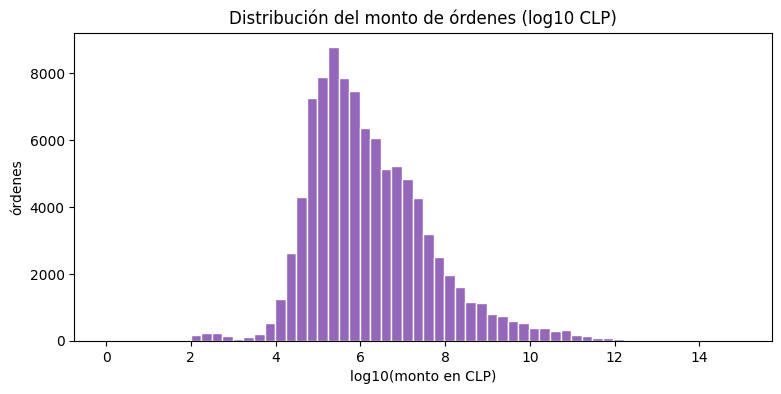

Mediana: CLP 937,125 | Media: CLP 19,952,745,032 | Total: CLP 1,939,925,588,520,503


In [10]:
montos = datos.filter('monto_oc_clp > 0').select('monto_oc_clp').toPandas()['monto_oc_clp']
plt.figure(figsize=(9, 4)); plt.hist(np.log10(montos), bins=60, color='tab:purple', edgecolor='white')
plt.title('Distribución del monto de órdenes (log10 CLP)'); plt.xlabel('log10(monto en CLP)'); plt.ylabel('órdenes'); plt.show()
print(f'Mediana: CLP {montos.median():,.0f} | Media: CLP {montos.mean():,.0f} | Total: CLP {montos.sum():,.0f}')

## 7. Concentración de proveedores y organismos

La medida usa el importe total de cada orden en estado `Aceptada`, una vez por `codigo_oc`. Es concentración de órdenes emitidas, no concentración de adjudicaciones ni de ofertas. El estado es importante: el portal mantiene en la descarga órdenes enviadas, en proceso, aceptadas, con solicitud de cancelación y recepción conforme.

La curva de Lorenz ordena proveedores desde el menor al mayor monto acumulado; el coeficiente de Gini resume la desigualdad de esa distribución entre 0 y 1. El cálculo incluye el punto inicial `(0, 0)`, que es necesario para integrar correctamente la curva. Una concentración alta es un indicador descriptivo para focalizar revisión, no demuestra por sí misma una conducta anticompetitiva: puede reflejar especialización, contratos de gran escala o el mecanismo de compra.

El corte por organismo, sector y región ayuda a separar concentración nacional de concentración localizada. Antes de atribuir una diferencia a una región conviene revisar el número de proveedores, el tipo de orden y la mezcla de sectores.

/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


/tmp/ipykernel_38688/2634562940.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(acum, poblacion)
/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


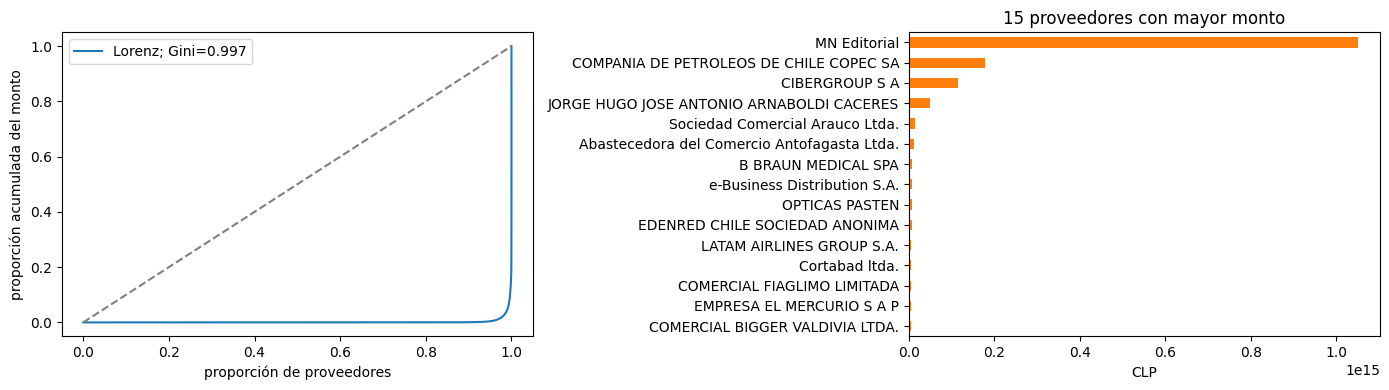

Gini de proveedores: 0.997


,codigo_proveedor,proveedor,monto_clp,ordenes
0,57338,MN Editorial,1050081842820366,2
1,26741,COMPANIA DE PETROLEOS DE CHILE COPEC SA,177253666262575,600
2,27266,CIBERGROUP S A,115586280663360,60
3,34478,JORGE HUGO JOSE ANTONIO ARNABOLDI CACERES,50014813139397,4
4,39621,Sociedad Comercial Arauco Ltda.,13752023326370,15
5,21971,Abastecedora del Comercio Antofagasta Ltda.,11365100845994,2
6,47740,B BRAUN MEDICAL SPA,8402998992099,1054
7,28109,e-Business Distribution S.A.,7735763698922,7
8,221601,OPTICAS PASTEN,6891418890328,5
9,27693,EDENRED CHILE SOCIEDAD ANONIMA,6867980381857,11


In [11]:
base_aceptada = datos.filter((F.col('estado_oc') == 'Aceptada') & F.col('monto_oc_clp').isNotNull() & (F.col('monto_oc_clp') > 0))
proveedores = (base_aceptada.filter(F.col('codigo_proveedor').isNotNull())
              .groupBy('codigo_proveedor', 'proveedor').agg(F.sum('monto_oc_clp').alias('monto_clp'), F.count('*').alias('ordenes')))
serie = proveedores.select('monto_clp').toPandas()['monto_clp'].sort_values().to_numpy()
acum = np.r_[0, np.cumsum(serie) / serie.sum()]
poblacion = np.linspace(0, 1, len(acum))
gini = 1 - 2 * np.trapz(acum, poblacion)
top_proveedores = proveedores.orderBy(F.desc('monto_clp')).limit(15).toPandas()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(poblacion, acum, label=f'Lorenz; Gini={gini:.3f}'); ax[0].plot([0,1], [0,1], '--', color='gray'); ax[0].legend(); ax[0].set(xlabel='proporción de proveedores', ylabel='proporción acumulada del monto')
top_proveedores.sort_values('monto_clp').plot.barh(x='proveedor', y='monto_clp', legend=False, ax=ax[1], color='tab:orange'); ax[1].set(xlabel='CLP', ylabel='', title='15 proveedores con mayor monto')
plt.tight_layout(); plt.show()
print(f'Gini de proveedores: {gini:.3f}')
top_proveedores

/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


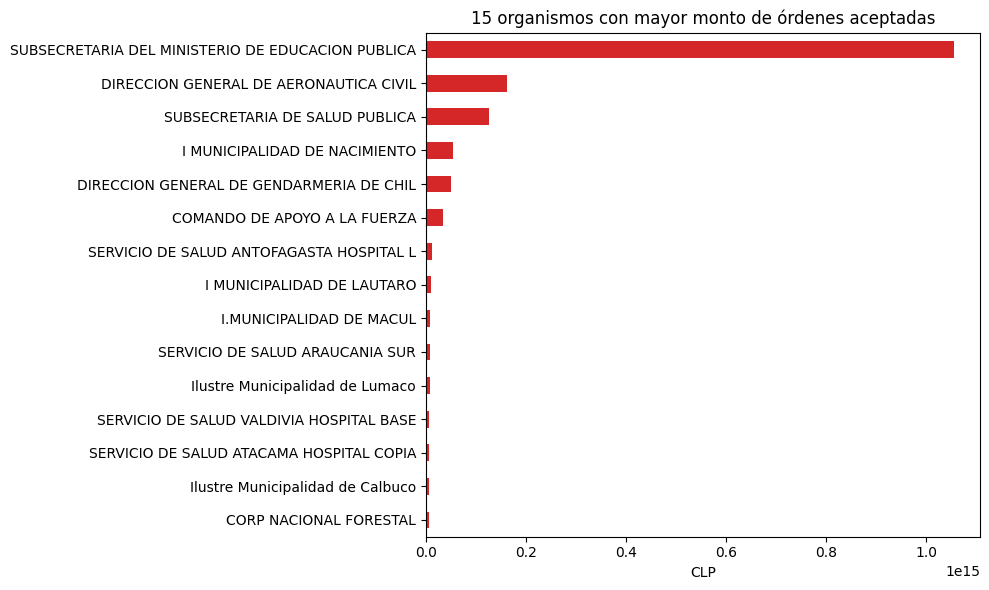

,organismo,sector,region_compra,monto_clp,ordenes
0,SUBSECRETARIA DEL MINISTERIO DE EDUCACION PUBLICA,"Gob. Central, Universidades",None,1054512654401597,815
1,DIRECCION GENERAL DE AERONAUTICA CIVIL,"Gob. Central, Universidades",None,163122283018436,321
2,SUBSECRETARIA DE SALUD PUBLICA,Salud,None,125771340618310,935
3,I MUNICIPALIDAD DE NACIMIENTO,Municipalidades,None,53370691559809,110
4,DIRECCION GENERAL DE GENDARMERIA DE CHIL,"Gob. Central, Universidades",None,49442978500197,2824
5,COMANDO DE APOYO A LA FUERZA,FFAA,None,34350156457666,3655
6,SERVICIO DE SALUD ANTOFAGASTA HOSPITAL L,Salud,None,12334230102522,420
7,I MUNICIPALIDAD DE LAUTARO,Municipalidades,None,9996947678845,146
8,I.MUNICIPALIDAD DE MACUL,Municipalidades,None,9011729234692,154
9,SERVICIO DE SALUD ARAUCANIA SUR,Salud,None,8657448856156,121


In [12]:
por_organismo = (base_aceptada.groupBy('organismo', 'sector', 'region_compra')
                 .agg(F.sum('monto_oc_clp').alias('monto_clp'), F.count('*').alias('ordenes'))
                 .orderBy(F.desc('monto_clp')).limit(15).toPandas())
por_organismo.sort_values('monto_clp').plot.barh(x='organismo', y='monto_clp', legend=False, figsize=(10, 6), color='tab:red')
plt.title('15 organismos con mayor monto de órdenes aceptadas'); plt.xlabel('CLP'); plt.ylabel(''); plt.tight_layout(); plt.show()
por_organismo

## 8. Canastas de productos

La transacción natural es la orden de compra y los ítems son códigos ONU. Antes de minar reglas se comprueba si hay suficiente coocurrencia: una orden con un solo producto no puede aportar una regla de asociación de dos ítems.

Si predominan las órdenes unitarias, no conviene forzar Apriori o FP-Growth sobre esta definición. Una alternativa defendible para una etapa posterior es agrupar productos por organismo y mes, pero cambia la pregunta: pasa de “qué productos aparecen en la misma orden” a “qué productos compra una entidad en el mismo período”. El notebook deja esa decisión condicionada a la evidencia de `pct_con_coocurrencia`.

In [13]:
canastas = datos.select(F.size('productos_onu').alias('n_productos'))
resumen_canasta = canastas.agg(
    F.count('*').alias('ordenes'), F.mean('n_productos').alias('media_productos'),
    F.expr('percentile_approx(n_productos, .5)').alias('mediana_productos'),
    F.sum(F.when(F.col('n_productos') >= 2, 1).otherwise(0)).alias('ordenes_con_coocurrencia'),
).toPandas()
resumen_canasta['pct_con_coocurrencia'] = 100 * resumen_canasta['ordenes_con_coocurrencia'] / resumen_canasta['ordenes']
resumen_canasta
# Si el porcentaje es bajo, la Parte V debe usar una canasta temporal por organismo en lugar de forzar reglas sobre órdenes unitarias.

/home/snah/micromamba/envs/spark310/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,ordenes,media_productos,mediana_productos,ordenes_con_coocurrencia,pct_con_coocurrencia
0,97226,1.952976,1,24388,25.083825


## 9. Procesamiento distribuido: RDD frente a DataFrame

Se calcula el monto por región con ambos estilos y se verifica igualdad mediante `exceptAll` en ambos sentidos. Así se controla que la comparación sea semántica antes de discutir rendimiento.

El RDD explicita el par clave–valor y la reducción; el DataFrame expresa la agregación declarativamente y deja a Catalyst la poda de columnas, el plan físico y el barajado. Para selección, filtrado y agregación, el DataFrame es el camino preferente. No se comparan tiempos de una sola corrida: un benchmark requiere repeticiones con calentamiento equivalente, el mismo estado de caché y estadísticas de varias mediciones.

In [14]:
df_region = (datos.filter('monto_oc_clp > 0').groupBy(F.coalesce('region_compra', F.lit('Sin región')).alias('region_compra'))
             .agg(F.sum('monto_oc_clp').cast('long').alias('monto_clp'), F.count('*').alias('ordenes')))
rdd_region = (datos.filter('monto_oc_clp > 0').select('region_compra', 'monto_oc_clp').rdd
              .map(lambda r: (r.region_compra or 'Sin región', (int(r.monto_oc_clp), 1)))
              .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
              .map(lambda x: (x[0], x[1][0], x[1][1])))
rdd_region_df = spark.createDataFrame(rdd_region, 'region_compra string, monto_clp long, ordenes long')
assert df_region.exceptAll(rdd_region_df).count() == 0 and rdd_region_df.exceptAll(df_region).count() == 0
print('Verificación correcta: RDD y DataFrame producen el mismo agregado.')
df_region.orderBy(F.desc('monto_clp')).show(20, truncate=False)

Verificación correcta: RDD y DataFrame producen el mismo agregado.


+------------------------------------------------+----------------+-------+
|region_compra                                   |monto_clp       |ordenes|
+------------------------------------------------+----------------+-------+
|Sin región                                      |1921435852151659|96427  |
|Región Metropolitana de Santiago                |8881699709226   |262    |
|Región de Antofagasta                           |3896922196517   |51     |
|Región de Coquimbo                              |3006509643055   |44     |
|Región del Biobío                               |1377086600621   |123    |
|Región de la Araucanía                          |683362001836    |47     |
|Región de Valparaíso                            |419781351608    |131    |
|Región del Maule                                |147275716026    |62     |
|Región de Los Ríos                              |48482046857     |16     |
|Región de Atacama                               |25009532621     |5      |
|Región de l

## 10. Particionado y cierre

El Parquet se particiona por `anio`, por lo que las consultas temporales pueden podar directorios completos. La última celda muestra el plan físico de un filtro por año; la evidencia buscada es un `PartitionFilters` sobre `anio`, no solo que el resultado tenga menos filas.

### Guía de interpretación

- Reporta siempre el universo: archivo `2007-1.csv`, órdenes con monto positivo y, para concentración, órdenes `Aceptada`.
- Distingue `MontoTotalOC_PesosChilenos` de la suma de líneas netas: ambos son controles distintos y pueden no coincidir por impuestos, descuentos, cargos o campos faltantes.
- No uses estos datos de órdenes para contar postores u ofertas. Para esa pregunta se necesita la descarga de licitaciones al grano correspondiente.
- No extrapoles este período a mecanismos o reglas vigentes tras reformas recientes a la Ley N° 19.886; el contexto normativo actual sirve para definir conceptos, no para reinterpretar retrospectivamente 2007. [Ley de Compras Públicas](https://www.chilecompra.cl/ley-de-compras-publicas/)

Con estas restricciones, el resultado es una base reproducible y auditable para las partes posteriores: similitud de productos, análisis temporal, minería de canastas o visualización web de agregados.

In [15]:
consulta_2007 = datos.filter('anio = 2007').groupBy('sector').agg(F.sum('monto_oc_clp').alias('monto_clp'))
consulta_2007.explain(mode='formatted')
print('Directorio Parquet:', RUTA_PARQUET)
spark.stop()

== Physical Plan ==
AdaptiveSparkPlan (6)
+- HashAggregate (5)
   +- Exchange (4)
      +- HashAggregate (3)
         +- Project (2)
            +- Scan parquet  (1)


(1) Scan parquet 
Output [3]: [sector#61901, monto_oc_clp#61906L, anio#61913]
Batched: true
Location: InMemoryFileIndex [file:/mnt/data/universidad/data_mining/proyecto/data/raw/ord_compras/oc-data-2007-1/salida_p1_chilecompra/ordenes_parquet]
PartitionFilters: [isnotnull(anio#61913), (anio#61913 = 2007)]
ReadSchema: struct<sector:string,monto_oc_clp:bigint>

(2) Project
Output [2]: [sector#61901, monto_oc_clp#61906L]
Input [3]: [sector#61901, monto_oc_clp#61906L, anio#61913]

(3) HashAggregate
Input [2]: [sector#61901, monto_oc_clp#61906L]
Keys [1]: [sector#61901]
Functions [1]: [partial_sum(monto_oc_clp#61906L)]
Aggregate Attributes [1]: [sum#62323L]
Results [2]: [sector#61901, sum#62324L]

(4) Exchange
Input [2]: [sector#61901, sum#62324L]
Arguments: hashpartitioning(sector#61901, 16), ENSURE_REQUIREMENTS, [plan_id=16